# Figure 4 — Partisan segregation in social infrastructure

Run the loading and plotting Python cells to reproduce all three panels from the plotting tables in `data/`. 
The preceding code cells are commented provenance, not runnable analysis. 
The notebook does not read Cuebiq files, user records, or place identifiers. 

## How the plotting tables were derived (reference only)

The commented cells summarize the upstream calculations. They are deliberately not executable here because the large source files are excluded from the replication folder.

In [1]:
# Panel a 
# For each MSA, log1p-transform the three counts of places reachable within
# a 15-minute walk, then fit weighted least squares:
# S_exp ~ S_res + log place counts + community_share + social_business_share
#       + public_outdoor_share + perc_black + perc_hisp + income_log
#       + perc_labor + perc_grad + ratio_poverty.
# The weights are weight_norm_msa. Rows with missing model variables are dropped,
# and zero-variance regressors are omitted within each MSA.
# Extract the three time-spent terms and HC1 robust standard errors from
# sandwich::vcovHC(fit, type="HC1"). The plot shows estimate +/- 1.96 SE.
# The 33 resulting rows are in data/fig4a_coefficients.csv.

In [2]:
# Panel b 
# Start with DISTINCT fsq_id, cat, S_poi, city rows from pois_catchment_loo.csv.
# Assign categories to Community, Social Business, Public Outdoor, or Baseline
# using the source notebook's category lists. Keep all categories when computing
# each city's median, then adjust each place's score:
# adjusted = (S_poi - median(S_poi within city)) / 2.
# For the four plotted groups only, calculate the median, quartiles, and
# 1.5-IQR whiskers. Store these summaries and the 113 outlying plotted values,
# rather than the 24,816 place records or their identifiers.
# See data/fig4b_box_stats.csv and data/fig4b_outliers.csv.

In [3]:
# Panel c 
# The source plotted four POI groups
# within Boston, Cambridge, and Somerville over a CartoDB Positron basemap.
# The 614 rendered markers were exported as normalized panel positions and
# group labels (data/fig4c_map_points.csv), with no place identifiers or raw
# geographic coordinates. The basemap is bundled separately as
# data/fig4c_basemap.png, preserving the original public cartographic layer.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Run from code_paper/ or from the repository root.
data_dir = Path("data") if Path("data/fig4a_coefficients.csv").is_file() else Path("code_paper/data")
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "pdf.fonttype": 42,
})

coefs = pd.read_csv(data_dir / "fig4a_coefficients.csv")
boxes = pd.read_csv(data_dir / "fig4b_box_stats.csv")
outliers = pd.read_csv(data_dir / "fig4b_outliers.csv")
map_points = pd.read_csv(data_dir / "fig4c_map_points.csv")
basemap = plt.imread(data_dir / "fig4c_basemap.png")
assert len(coefs) == 33 and len(boxes) == 4 and len(map_points) == 614

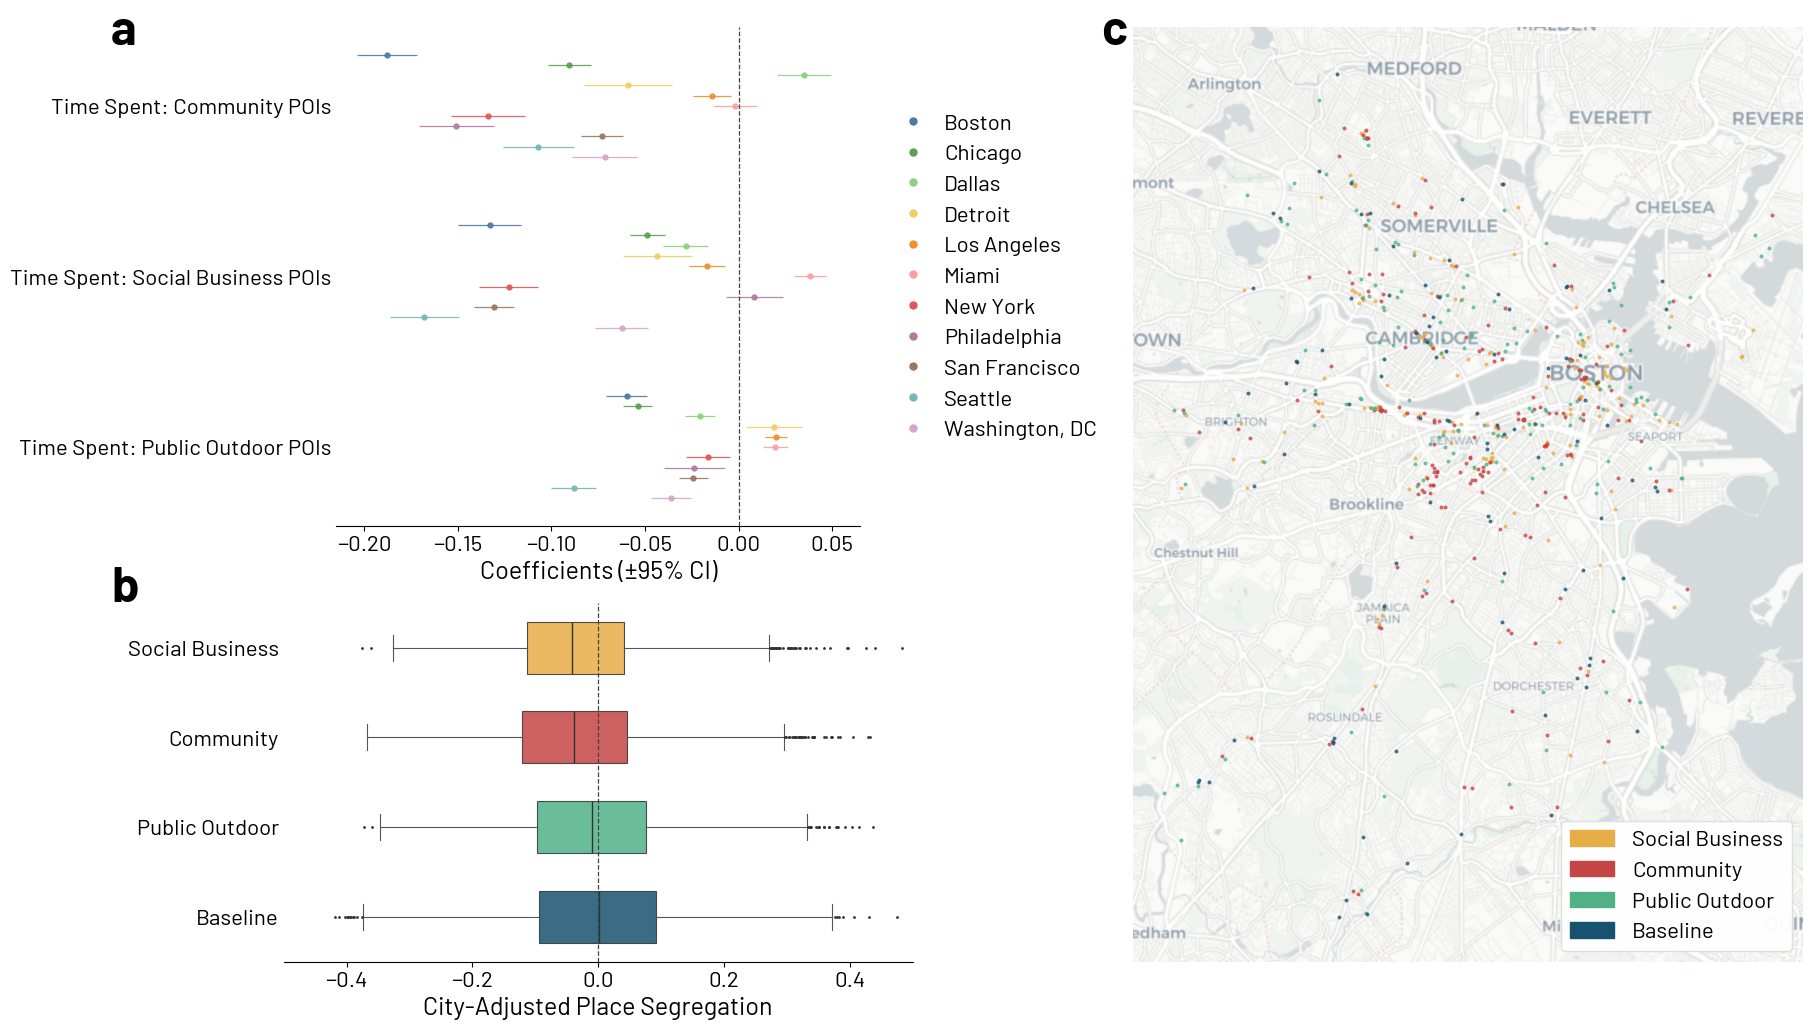

In [5]:
city_order = [
    "Boston", "Chicago", "Dallas", "Detroit", "Los Angeles", "Miami",
    "New York", "Philadelphia", "San Francisco", "Seattle", "Washington DC",
]
city_palette = [
    "#4E79A7", "#59A14F", "#8CD17D", "#F1CE63", "#F28E2B",
    "#FF9DA7", "#E15759", "#B07AA1", "#9C755F", "#76B7B2", "#D4A6C8",
]
city_colors = dict(zip(city_order, city_palette))
term_order = ["community_share", "social_business_share", "public_outdoor_share"]
term_labels = ["Time Spent: Community POIs", "Time Spent: Social Business POIs",
               "Time Spent: Public Outdoor POIs"]
group_order = ["Social Business", "Community", "Public Outdoor", "Baseline"]
group_colors = {
    "Social Business": "#E7AD47", "Community": "#C54444",
    "Public Outdoor": "#50B189", "Baseline": "#175370",
}

# Apply the bundled font immediately before drawing the figure.
from matplotlib import font_manager
font_dirs = ['font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams['font.family'] = 'Barlow'

fig = plt.figure(figsize=(18, 10.5), facecolor="white")
layout = fig.add_gridspec(
    2, 2, left=0.17, right=0.985, top=0.95, bottom=0.06,
    width_ratios=[1.15, 1], height_ratios=[1, 0.72],
    wspace=0.10, hspace=0.18,
)
top_left = layout[0, 0].subgridspec(1, 2, width_ratios=[3.25, 1.25], wspace=0.06)
ax_a = fig.add_subplot(top_left[0, 0])
legend_ax = fig.add_subplot(top_left[0, 1])
legend_ax.axis("off")

# a: separate city WLS coefficients and their robust 95% intervals.
for term_index, term in enumerate(term_order):
    center_y = 2 - term_index
    for city_index, city in enumerate(city_order):
        value = coefs.loc[(coefs.city == city) & (coefs.term == term)].iloc[0]
        y = center_y + 0.30 - 0.06 * city_index
        ax_a.errorbar(value.estimate, y, xerr=1.96 * value.standard_error,
                      fmt="o", color=city_colors[city], markersize=3.5,
                      elinewidth=0.9, capsize=0, alpha=0.9)
ax_a.axvline(0, color="#444444", linestyle="--", linewidth=0.9)
ax_a.set_yticks([2, 1, 0], term_labels)
ax_a.set_xlim(-0.215, 0.065)
ax_a.set_xticks([-0.20, -0.15, -0.10, -0.05, 0, 0.05])
ax_a.set_ylim(-0.46, 2.46)
ax_a.set_xlabel("Coefficients (±95% CI)")
ax_a.tick_params(axis="y", length=0)
ax_a.spines[["top", "right", "left"]].set_visible(False)
legend_ax.legend(
    handles=[Line2D([0], [0], marker="o", linestyle="", color=city_colors[c],
                    markersize=5, label=c.replace("Washington DC", "Washington, DC"))
             for c in city_order],
    loc="center left", frameon=False, fontsize=16, handletextpad=0.4,
    borderaxespad=0,
)

# b: boxplot summaries plus the outlying plotted points; no place-level data.
ax_b = fig.add_subplot(layout[1, 0])
# Center the boxplot beneath the coefficient axes, at 120% of their width.
a_bounds = ax_a.get_position()
b_bounds = ax_b.get_position()
b_width = 1.2 * a_bounds.width
ax_b.set_position([
    a_bounds.x0 + (a_bounds.width - b_width) / 2,
    b_bounds.y0, b_width, b_bounds.height,
])
stats = []
for group in group_order:
    row = boxes.set_index("group").loc[group]
    stats.append(dict(
        label=group, med=row["median"], q1=row.q1, q3=row.q3,
        whislo=row.whisker_low, whishi=row.whisker_high,
        fliers=outliers.loc[outliers.group == group, "adjusted_segregation"].to_numpy(),
    ))
artists = ax_b.bxp(
    stats, positions=[4, 3, 2, 1], vert=False, patch_artist=True,
    widths=0.58, showfliers=True,
    boxprops=dict(edgecolor="#333333", linewidth=0.8),
    medianprops=dict(color="#333333", linewidth=1),
    whiskerprops=dict(color="#555555", linewidth=0.8),
    capprops=dict(color="#555555", linewidth=0.8),
    flierprops=dict(marker=".", markersize=2, markeredgecolor="#333333"),
)
for artist, group in zip(artists["boxes"], group_order):
    artist.set_facecolor(group_colors[group])
    artist.set_alpha(0.85)
ax_b.axvline(0, color="#444444", linestyle="--", linewidth=0.9)
ax_b.set_xlim(-0.5, 0.5)
ax_b.set_yticks([4, 3, 2, 1], group_order)
ax_b.set_xlabel("City-Adjusted Place Segregation")
ax_b.tick_params(axis="y", length=0)
ax_b.spines[["top", "right", "left"]].set_visible(False)

# c: original map markers as normalized display coordinates, on the saved
# public street-map layer. Scatter uses the same group colors as panel b.
ax_c = fig.add_subplot(layout[:, 1])
# Size the map from the upper edge of a to the lower edge of b, preserving
# the original basemap aspect ratio and the common right margin.
map_height = a_bounds.y1 - b_bounds.y0
map_width = (map_height * fig.get_figheight() / fig.get_figwidth()
             * basemap.shape[1] / basemap.shape[0])
ax_c.set_position([0.985 - map_width, b_bounds.y0, map_width, map_height])
ax_c.imshow(basemap, extent=(0, 1, 0, 1), origin="upper", aspect="auto")
for group in group_order:
    subset = map_points.loc[map_points.group == group]
    ax_c.scatter(subset.x_panel, subset.y_panel, s=8,
                 color=group_colors[group], alpha=0.8, linewidths=0)
ax_c.set_xlim(0, 1)
ax_c.set_ylim(0, 1)
ax_c.set_box_aspect(basemap.shape[0] / basemap.shape[1])
ax_c.set_anchor("N")
ax_c.axis("off")
ax_c.legend(
    handles=[Patch(color=group_colors[g], label=g) for g in group_order],
    loc="lower right", fontsize=16, frameon=True, facecolor="white",
    edgecolor="#dddddd", framealpha=0.95,
)

fig.text(0.045, 0.967, "a", fontsize=35, fontweight="bold", va="top")
fig.text(0.045, 0.437, "b", fontsize=35, fontweight="bold", va="top")
fig.text(ax_c.get_position().x0 - 0.018, 0.967, "c", fontsize=35, fontweight="bold", va="top")
fig.savefig("fig_4.pdf", bbox_inches="tight")
plt.show()